# Pandas 응용 - 실전 데이터 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한국어 폰트 설정
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

# 음수 기호 표시
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 1. 시계열 데이터 분석 (Time Series)

In [2]:
# 시계열 데이터 생성
dates = pd.date_range('2024-01-01', periods=365, freq='D')
data = np.random.randn(365).cumsum() + 100  # 누적합

ts_df = pd.DataFrame({
    'Date': dates,
    'Price': data
})
ts_df.set_index('Date', inplace=True)
ts_df.head(10)

,Price
Date,
2024-01-01,98.803055
2024-01-02,98.077816
2024-01-03,97.131354
2024-01-04,95.044066
2024-01-05,95.140037
2024-01-06,94.956512
2024-01-07,94.272427
2024-01-08,92.026296
2024-01-09,92.485062


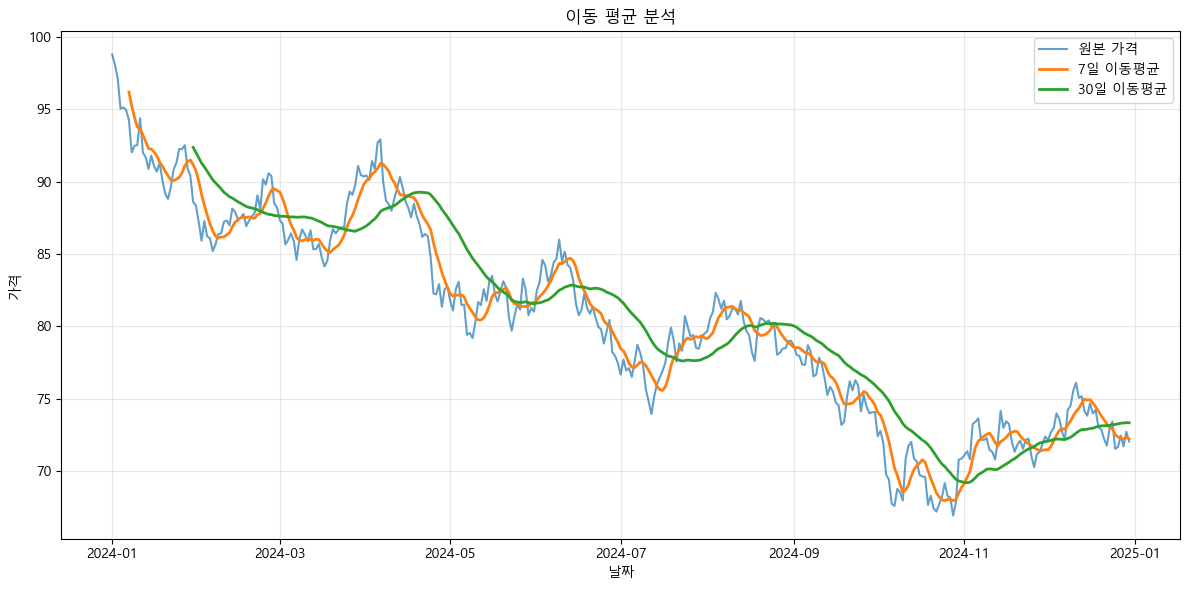

In [3]:
# 이동 평균 (Moving Average)
ts_df['MA_7'] = ts_df['Price'].rolling(window=7).mean()  # 7일 이동평균
ts_df['MA_30'] = ts_df['Price'].rolling(window=30).mean()  # 30일 이동평균

plt.figure(figsize=(12, 6))
plt.plot(ts_df.index, ts_df['Price'], label='원본 가격', alpha=0.7)
plt.plot(ts_df.index, ts_df['MA_7'], label='7일 이동평균', linewidth=2)
plt.plot(ts_df.index, ts_df['MA_30'], label='30일 이동평균', linewidth=2)
plt.xlabel('날짜')
plt.ylabel('가격')
plt.title('이동 평균 분석')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/pandas_4_14.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# 일일 수익률 계산
ts_df['Return'] = ts_df['Price'].pct_change() * 100  # 일일 수익률 (%)
ts_df['Cumulative_Return'] = (1 + ts_df['Return'] / 100).cumprod() - 1

print(f'평균 수익률: {ts_df["Return"].mean():.4f}%')
print(f'수익률 표준편차: {ts_df["Return"].std():.4f}%')
print(f'누적 수익률: {ts_df["Cumulative_Return"].iloc[-1] * 100:.2f}%')
print(f'최대 손실: {ts_df["Return"].min():.4f}%')
print(f'최대 수익: {ts_df["Return"].max():.4f}%')

평균 수익률: -0.0794%
수익률 표준편차: 1.2131%
누적 수익률: -27.10%
최대 손실: -3.1658%
최대 수익: 4.3534%


In [5]:
# 월별 통계
ts_df['Month'] = ts_df.index.month
ts_df['Year'] = ts_df.index.year

monthly_stats = ts_df.groupby('Month')['Price'].agg(['mean', 'min', 'max', 'std'])
print('월별 가격 통계:')
print(monthly_stats)

월별 가격 통계:
            mean        min        max       std
Month                                           
1      92.239889  88.345971  98.803055  2.645114
2      87.623312  85.200611  90.585985  1.374787
3      86.850670  84.140111  91.088519  1.828412
4      87.567122  81.352383  92.930862  3.225423
5      81.570211  79.178622  83.485662  1.180663
6      81.972522  77.458967  86.001494  2.327738
7      77.763340  73.934206  80.710601  1.623505
8      80.076975  77.605845  82.317738  1.248157
9      75.947878  73.179763  78.693994  1.611391
10     69.358533  66.909847  72.764437  1.704901
11     72.024751  70.251308  74.150428  0.954305
12     73.326868  71.518849  76.094466  1.246856


# 2. 데이터 전처리 및 결측값 처리

In [6]:
# 결측값 포함 데이터 생성
data_with_missing = pd.DataFrame({
    'A': [1, 2, np.nan, 4, 5, np.nan, 7],
    'B': [10, np.nan, np.nan, 40, 50, 60, 70],
    'C': [100, 200, 300, 400, 500, 600, 700]
})

print('결측값 개수:')
print(data_with_missing.isnull().sum())
print('\n결측값 비율:')
print(data_with_missing.isnull().sum() / len(data_with_missing) * 100)

결측값 개수:
A    2
B    2
C    0
dtype: int64

결측값 비율:
A    28.571429
B    28.571429
C     0.000000
dtype: float64


In [7]:
# 다양한 결측값 처리 방법
# 방법1: 결측값 제거
df_dropna = data_with_missing.dropna()
print('결측값 제거 후:')
print(df_dropna)

# 방법2: 평균값으로 채우기
df_fillmean = data_with_missing.copy()
df_fillmean['A'].fillna(df_fillmean['A'].mean(), inplace=True)
df_fillmean['B'].fillna(df_fillmean['B'].mean(), inplace=True)
print('\n평균값으로 채운 후:')
print(df_fillmean)

# 방법3: 전후 값으로 채우기 (Interpolation)
df_interpolate = data_with_missing.copy()
df_interpolate['A'] = df_interpolate['A'].interpolate()
df_interpolate['B'] = df_interpolate['B'].interpolate()
print('\n보간법으로 채운 후:')
print(df_interpolate)

결측값 제거 후:
     A     B    C
0  1.0  10.0  100
3  4.0  40.0  400
4  5.0  50.0  500
6  7.0  70.0  700

평균값으로 채운 후:
     A     B    C
0  1.0  10.0  100
1  2.0  46.0  200
2  3.8  46.0  300
3  4.0  40.0  400
4  5.0  50.0  500
5  3.8  60.0  600
6  7.0  70.0  700

보간법으로 채운 후:
     A     B    C
0  1.0  10.0  100
1  2.0  20.0  200
2  3.0  30.0  300
3  4.0  40.0  400
4  5.0  50.0  500
5  6.0  60.0  600
6  7.0  70.0  700


C:\Users\User\AppData\Local\Temp\ipykernel_7404\1208703249.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fillmean['A'].fillna(df_fillmean['A'].mean(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_7404\1208703249.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

# 3. 이상치 (Outlier) 탐지 및 제거

In [8]:
# 이상치 포함 데이터
np.random.seed(42)
normal_data = np.random.normal(100, 10, 100)
outliers = np.array([150, 180, 25, 30])  # 이상치
data_with_outliers = np.concatenate([normal_data, outliers])

df_outliers = pd.DataFrame({'Value': data_with_outliers})

# IQR (Interquartile Range) 방법
Q1 = df_outliers['Value'].quantile(0.25)
Q3 = df_outliers['Value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:.2f}')
print(f'Q3: {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'하한: {lower_bound:.2f}')
print(f'상한: {upper_bound:.2f}')

# 이상치 식별
outlier_mask = (df_outliers['Value'] < lower_bound) | (df_outliers['Value'] > upper_bound)
print(f'\n이상치 개수: {outlier_mask.sum()}')
print(f'이상치: {df_outliers[outlier_mask].values.flatten()}')

Q1: 93.87
Q3: 105.01
IQR: 11.13
하한: 77.17
상한: 121.71

이상치 개수: 5
이상치: [ 73.80254896 150.         180.          25.          30.        ]


Z-Score 방법으로 탐지된 이상치 개수: 4
이상치: [150. 180.  25.  30.]


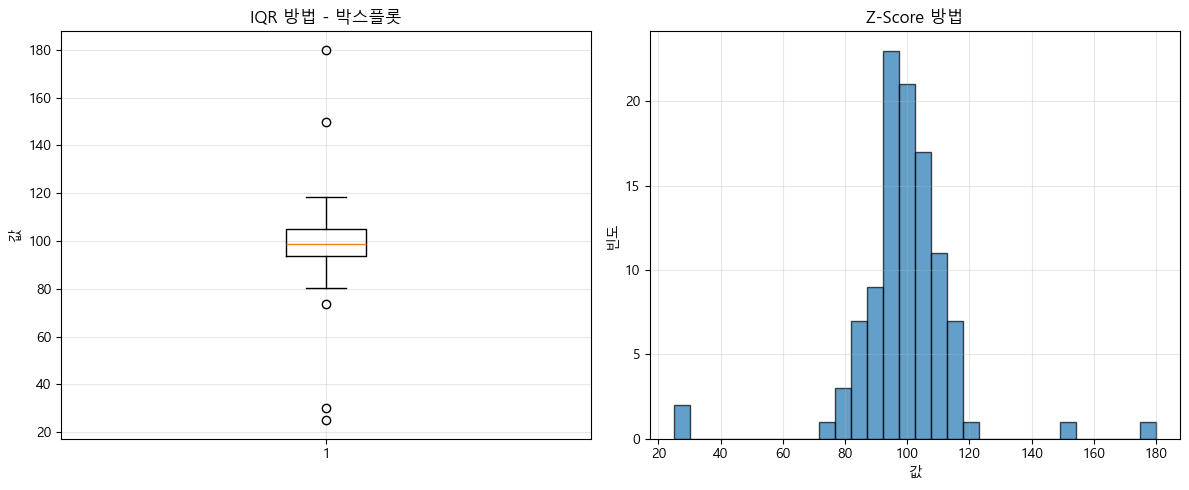

In [9]:
# Z-Score 방법
from scipy import stats

z_scores = np.abs(stats.zscore(df_outliers['Value']))
outlier_mask_zscore = z_scores > 3  # 3 표준편차 이상

print(f'Z-Score 방법으로 탐지된 이상치 개수: {outlier_mask_zscore.sum()}')
print(f'이상치: {df_outliers[outlier_mask_zscore].values.flatten()}')

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df_outliers['Value'])
plt.ylabel('값')
plt.title('IQR 방법 - 박스플롯')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df_outliers['Value'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('값')
plt.ylabel('빈도')
plt.title('Z-Score 방법')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/pandas_12_20.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 카테고리 데이터 처리

In [10]:
# 카테고리 데이터
df_category = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Red', 'Green', 'Blue', 'Red'],
    'Size': ['S', 'M', 'L', 'M', 'S', 'L'],
    'Price': [100, 150, 200, 120, 110, 180]
})

print('원본 데이터:')
print(df_category)

# One-Hot Encoding
df_onehot = pd.get_dummies(df_category, columns=['Color', 'Size'])
print('\nOne-Hot Encoding 후:')
print(df_onehot)

원본 데이터:
   Color Size  Price
0    Red    S    100
1   Blue    M    150
2    Red    L    200
3  Green    M    120
4   Blue    S    110
5    Red    L    180

One-Hot Encoding 후:
   Price  Color_Blue  Color_Green  Color_Red  Size_L  Size_M  Size_S
0    100       False        False       True   False   False    True
1    150        True        False      False   False    True   False
2    200       False        False       True    True   False   False
3    120       False         True      False   False    True   False
4    110        True        False      False   False   False    True
5    180       False        False       True    True   False   False


In [11]:
# Label Encoding
color_mapping = {'Red': 0, 'Blue': 1, 'Green': 2}
size_mapping = {'S': 0, 'M': 1, 'L': 2}

df_label = df_category.copy()
df_label['Color'] = df_label['Color'].map(color_mapping)
df_label['Size'] = df_label['Size'].map(size_mapping)

print('Label Encoding 후:')
print(df_label)

Label Encoding 후:
   Color  Size  Price
0      0     0    100
1      1     1    150
2      0     2    200
3      2     1    120
4      1     0    110
5      0     2    180


# 5. 다중 인덱싱 (MultiIndex)

In [12]:
# 다중 인덱스 생성
arrays = [
    ['Sales', 'Sales', 'IT', 'IT', 'HR', 'HR'],
    ['2024-Q1', '2024-Q2', '2024-Q1', '2024-Q2', '2024-Q1', '2024-Q2']
]
index = pd.MultiIndex.from_arrays(arrays, names=['Department', 'Quarter'])

df_multiindex = pd.DataFrame({
    'Revenue': [100000, 120000, 80000, 95000, 50000, 55000],
    'Expenses': [60000, 70000, 50000, 60000, 30000, 35000]
}, index=index)

print('다중 인덱스 DataFrame:')
print(df_multiindex)

# 접근
print('\nSales 부서 데이터:')
print(df_multiindex.loc['Sales'])

다중 인덱스 DataFrame:
                    Revenue  Expenses
Department Quarter                   
Sales      2024-Q1   100000     60000
           2024-Q2   120000     70000
IT         2024-Q1    80000     50000
           2024-Q2    95000     60000
HR         2024-Q1    50000     30000
           2024-Q2    55000     35000

Sales 부서 데이터:
         Revenue  Expenses
Quarter                   
2024-Q1   100000     60000
2024-Q2   120000     70000


# 6. 데이터 다시 구성 (Reshape)

In [13]:
# Stack과 Unstack
df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6],
    'C': [7, 8, 9]
}, index=['X', 'Y', 'Z'])

print('원본 DataFrame:')
print(df)

print('\nStack (넓은 형식 → 좁은 형식):')
stacked = df.stack()
print(stacked)

print('\nUnstack (좁은 형식 → 넓은 형식):')
unstacked = stacked.unstack()
print(unstacked)

원본 DataFrame:
   A  B  C
X  1  4  7
Y  2  5  8
Z  3  6  9

Stack (넓은 형식 → 좁은 형식):
X  A    1
   B    4
   C    7
Y  A    2
   B    5
   C    8
Z  A    3
   B    6
   C    9
dtype: int64

Unstack (좁은 형식 → 넓은 형식):
   A  B  C
X  1  4  7
Y  2  5  8
Z  3  6  9


# 7. 고급 그룹 분석

In [14]:
# 판매 데이터
sales_df = pd.DataFrame({
    'Region': ['North', 'South', 'North', 'South', 'East', 'West', 'East', 'West'],
    'Product': ['A', 'A', 'B', 'B', 'A', 'B', 'A', 'B'],
    'Sales': [100, 150, 120, 180, 110, 140, 130, 160],
    'Quantity': [10, 15, 12, 18, 11, 14, 13, 16]
})

print('원본 데이터:')
print(sales_df)

# 지역별, 제품별 그룹화
grouped = sales_df.groupby(['Region', 'Product'])['Sales'].agg(['sum', 'mean', 'count'])
print('\n지역별, 제품별 판매액:')
print(grouped)

원본 데이터:
  Region Product  Sales  Quantity
0  North       A    100        10
1  South       A    150        15
2  North       B    120        12
3  South       B    180        18
4   East       A    110        11
5   West       B    140        14
6   East       A    130        13
7   West       B    160        16

지역별, 제품별 판매액:
                sum   mean  count
Region Product                   
East   A        240  120.0      2
North  A        100  100.0      1
       B        120  120.0      1
South  A        150  150.0      1
       B        180  180.0      1
West   B        300  150.0      2


In [15]:
# 데이터 변환 (Transform)
# 각 지역의 평균 판매액
sales_df['Region_Mean'] = sales_df.groupby('Region')['Sales'].transform('mean')
sales_df['Sales_vs_Mean'] = sales_df['Sales'] - sales_df['Region_Mean']

print('지역별 평균 대비 판매액:')
print(sales_df[['Region', 'Sales', 'Region_Mean', 'Sales_vs_Mean']])

지역별 평균 대비 판매액:
  Region  Sales  Region_Mean  Sales_vs_Mean
0  North    100        110.0          -10.0
1  South    150        165.0          -15.0
2  North    120        110.0           10.0
3  South    180        165.0           15.0
4   East    110        120.0          -10.0
5   West    140        150.0          -10.0
6   East    130        120.0           10.0
7   West    160        150.0           10.0


# 8. 문자열 처리

In [16]:
# 문자열 데이터
df_str = pd.DataFrame({
    'Name': ['john doe', 'JANE SMITH', 'bob JOHNSON'],
    'Email': ['john@example.com', 'jane@example.com', 'bob@example.com']
})

print('원본 데이터:')
print(df_str)

# 문자열 메서드
print('\n대문자 변환:')
print(df_str['Name'].str.upper())

print('\n소문자 변환:')
print(df_str['Name'].str.lower())

print('\n첫 글자 대문자:')
print(df_str['Name'].str.title())

print('\n길이:')
print(df_str['Name'].str.len())

print('\n특정 문자 포함 여부:')
print(df_str['Name'].str.contains('john', case=False))

print('\n특정 패턴 추출:')
print(df_str['Email'].str.extract(r'(\w+)@'))

원본 데이터:
          Name             Email
0     john doe  john@example.com
1   JANE SMITH  jane@example.com
2  bob JOHNSON   bob@example.com

대문자 변환:
0       JOHN DOE
1     JANE SMITH
2    BOB JOHNSON
Name: Name, dtype: object

소문자 변환:
0       john doe
1     jane smith
2    bob johnson
Name: Name, dtype: object

첫 글자 대문자:
0       John Doe
1     Jane Smith
2    Bob Johnson
Name: Name, dtype: object

길이:
0     8
1    10
2    11
Name: Name, dtype: int64

특정 문자 포함 여부:
0     True
1    False
2     True
Name: Name, dtype: bool

특정 패턴 추출:
      0
0  john
1  jane
2   bob


# 9. 피벗 테이블 심화

In [17]:
# 판매 데이터
pivot_data = pd.DataFrame({
    'Month': ['Jan', 'Jan', 'Feb', 'Feb', 'Mar', 'Mar'],
    'Region': ['North', 'South', 'North', 'South', 'North', 'South'],
    'Sales': [100, 150, 120, 180, 110, 200],
    'Profit': [20, 30, 25, 40, 22, 45]
})

# 피벗 테이블 생성
pivot_table = pd.pivot_table(pivot_data, 
                            values=['Sales', 'Profit'],
                            index='Month',
                            columns='Region',
                            aggfunc='sum',
                            margins=True)  # 합계 포함

print('피벗 테이블:')
print(pivot_table)

피벗 테이블:
       Profit            Sales           
Region  North South  All North South  All
Month                                    
Feb        25    40   65   120   180  300
Jan        20    30   50   100   150  250
Mar        22    45   67   110   200  310
All        67   115  182   330   530  860


# 10. 데이터 품질 검사

In [18]:
# 품질 체크 함수
def check_data_quality(df):
    print('=== 데이터 품질 검사 ===')
    print(f'행의 개수: {len(df)}')
    print(f'열의 개수: {len(df.columns)}')
    print(f'\n데이터 타입:')
    print(df.dtypes)
    print(f'\n결측값:')
    print(df.isnull().sum())
    print(f'\n중복된 행: {df.duplicated().sum()}개')
    print(f'\n통계 요약:')
    print(df.describe())

# 테스트 데이터
test_df = pd.DataFrame({
    'Age': [25, 30, np.nan, 35, 25],
    'Salary': [50000, 60000, 70000, 80000, 50000],
    'Score': [85, 90, 88, 92, 85]
})

check_data_quality(test_df)

=== 데이터 품질 검사 ===
행의 개수: 5
열의 개수: 3

데이터 타입:
Age       float64
Salary      int64
Score       int64
dtype: object

결측값:
Age       1
Salary    0
Score     0
dtype: int64

중복된 행: 1개

통계 요약:
             Age       Salary      Score
count   4.000000      5.00000   5.000000
mean   28.750000  62000.00000  88.000000
std     4.787136  13038.40481   3.082207
min    25.000000  50000.00000  85.000000
25%    25.000000  50000.00000  85.000000
50%    27.500000  60000.00000  88.000000
75%    31.250000  70000.00000  90.000000
max    35.000000  80000.00000  92.000000


# 11. 고급 조건부 필터링

In [19]:
# 필터링 데이터
df_filter = pd.DataFrame({
    'Product': ['A', 'B', 'C', 'D', 'E'],
    'Price': [100, 200, 150, 300, 250],
    'Stock': [10, 5, 20, 15, 8]
})

print('원본 데이터:')
print(df_filter)

# 조건1: 가격이 150 이상
condition1 = df_filter['Price'] >= 150

# 조건2: 재고가 10 이상
condition2 = df_filter['Stock'] >= 10

# 조건1 AND 조건2
result = df_filter[condition1 & condition2]
print('\n가격 >= 150 AND 재고 >= 10:')
print(result)

# 조건1 OR 조건2
result = df_filter[condition1 | condition2]
print('\n가격 >= 150 OR 재고 >= 10:')
print(result)

# NOT 조건1
result = df_filter[~condition1]
print('\n가격 < 150:')
print(result)

원본 데이터:
  Product  Price  Stock
0       A    100     10
1       B    200      5
2       C    150     20
3       D    300     15
4       E    250      8

가격 >= 150 AND 재고 >= 10:
  Product  Price  Stock
2       C    150     20
3       D    300     15

가격 >= 150 OR 재고 >= 10:
  Product  Price  Stock
0       A    100     10
1       B    200      5
2       C    150     20
3       D    300     15
4       E    250      8

가격 < 150:
  Product  Price  Stock
0       A    100     10
